In [56]:
import numpy as np
import matplotlib.pyplot as plt

In [57]:
#Defining parameters

N = 100
t = 1.0
Delta0  = 1.0
mu0=4.0



In [58]:
#Site dependent chemical potentials

mu = np.zeros(N)

#Site dependent pairing

Delta = np.zeros(N)

In [59]:
print(mu)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


In [13]:
#Building interface

for i in range(N):
    #Superconducting region
    if i <N//2:
        mu[i] = 0
        Delta[i] = Delta0
    else:
        #Backscattering region
        mu[i] = mu0
        Delta[i]= 0

In [14]:
#Hamiltonian

h = np.zeros((N,N))

for i in range(N):
    h[i,i] = -mu[i]

for i in range(N-1):
    h[i,i+1] = -t
    h[i+1,i] = -t

#Pairing matrix

pair = np.zeros((N,N))

for i in range(N-1):
    pair[i,i+1] = Delta[i]
    pair[i+1,i] = -Delta[i]

#BdG Hamiltonian

top = np.hstack((h,pair))
bottom = np.hstack((-pair.T,-h.T))

Hbdg = np.vstack((top,bottom))
    

In [15]:
#Diagonalization

E, V = np.linalg.eigh(Hbdg)

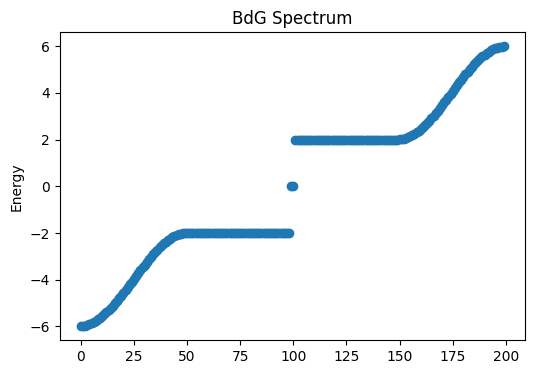

In [16]:
#Plot Spectrum

plt.figure(figsize = (6,4))
plt.plot(E,'o')
plt.ylabel("Energy")
plt.title("BdG Spectrum")
plt.show()

In [17]:
#Find lowest energy state

idx = np.argmin(np.abs(E))

u = V[:N,idx]
v = V[N:,idx]

density = np.abs(u)**2 + np.abs(v)**2

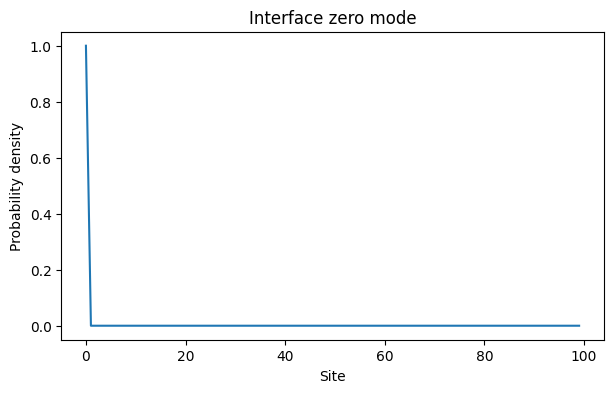

Lowest energy = 3.11305607072287e-16


In [18]:
#plot of wavefunction

plt.figure(figsize = (7,4))
plt.plot(density)
plt.xlabel("Site")
plt.ylabel("Probability density")
plt.title("Interface zero mode")
plt.show()

print("Lowest energy =", E[idx])

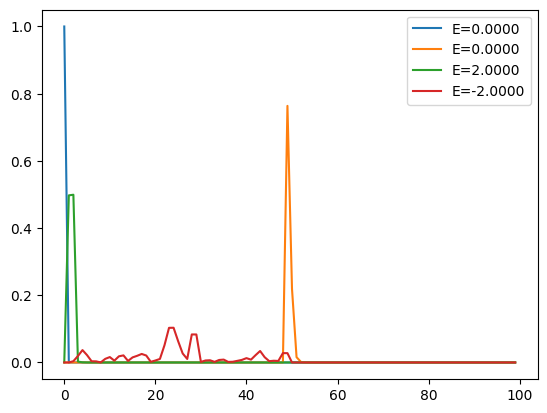

In [19]:
#Excited states

for n in range(4):

    idx = np.argsort(np.abs(E))[n]

    u = V[:N, idx]
    v = V[N:, idx]

    density = np.abs(u)**2 + np.abs(v)**2

    plt.plot(density, label=f"E={E[idx]:.4f}")

plt.legend()
plt.show()

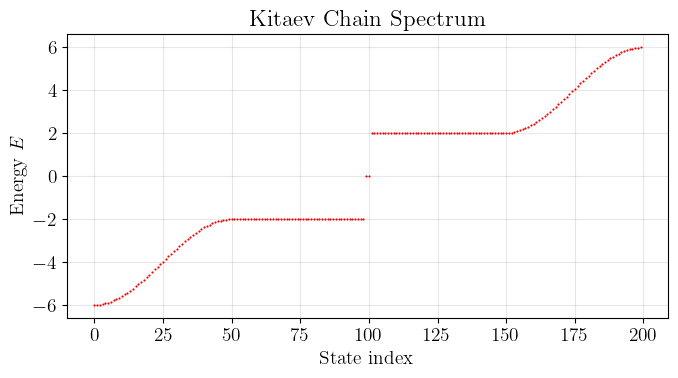

In [20]:
# Gráfico mais bonito
plt.rcParams.update({
    "text.usetex": True,      # usa LaTeX
    "font.family": "serif",
    "font.size": 14,
})

fig, ax = plt.subplots(figsize=(7,4))

ax.plot(
    E,
    'o',
    color='red',
    markersize=1,     # pontos menores
    markeredgewidth=0.5
)

ax.set_xlabel(r"State index")
ax.set_ylabel(r"Energy $E$")
ax.set_title(r"Kitaev Chain Spectrum")

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [44]:
#Josephson Effect - Current Periodicity

N = 100
left = 45
right = 55
Delta0 = 0

#Valor teste para phi

phi = np.pi

In [45]:
DeltaL = Delta0*np.exp(-1j*phi/2)
DeltaR = Delta0*np.exp(+1j*phi/2)

pair = np.zeros((N,N), dtype = complex)

for i in range(N-1):
    if i<left:
        pair[i,i+1] = DeltaL
        pair[i+1,i]  = -DeltaL
    if i>right:
        pair[i,i+1] = DeltaR
        pair[i+1,i] = -DeltaR

In [46]:
phis = np.linspace(0,8*np.pi,400)
ground_energy = []

In [47]:
for phi in phis:
    #Construir H
    E, V = np.linalg.eigh(Hbdg)
    Eneg = E[E<0]
    Egs = 0.5*np.sum(Eneg)
    
    ground_energy.append(Egs)

In [48]:
spectra = []

for phi in phis:
    spectra.append(E)

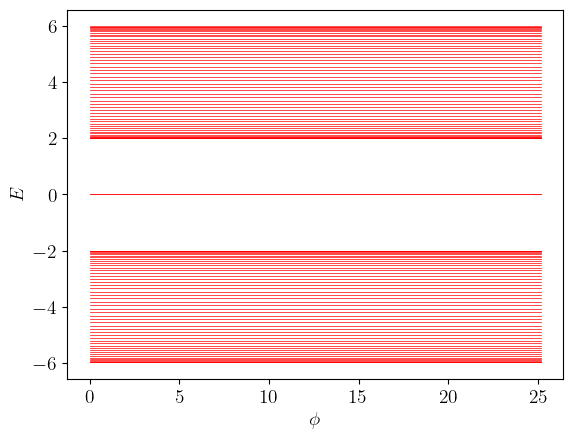

In [49]:
spectra = np.array(spectra)

for n in range(spectra.shape[1]):
    plt.plot(phis,spectra[:,n], 'r', lw=0.5)

plt.xlabel(r'$\phi$')
plt.ylabel(r'$E$')
plt.show()

In [53]:
ground_energy = np.array(ground_energy)
current = np.gradient(ground_energy,phis)

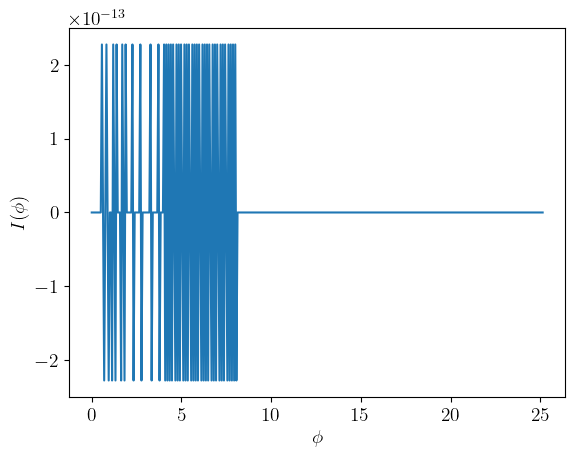

In [55]:
plt.plot(phis,current)
plt.xlabel(r'$\phi$')
plt.ylabel(r'$I(\phi)$')
plt.show()